In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)

In [3]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)

ocean_mask = ~sst.isel(time = 1).sst.isnull()

## Bar Code

In [4]:
fp = '/data/jmex/ERA5/monthly/recent/era5_t2m.nc'
t2m = xr.open_dataset(fp).sel(valid_time = slice(None, None))

#change variable names
t2m = t2m.rename({'latitude':'lat', 'longitude':'lon'})
t2m = t2m.drop_vars(['number', 'expver'])


t2m = t2m.rename({'valid_time':'time'})
t2m['time'] = pd.to_datetime(t2m['time'].values.astype(str), format='%Y-%m-%d')




In [5]:
#aso only
t2m = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [6]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

In [18]:
#mask to have ocean only
t2m = t2m.where(masks.open_ocean.isin([1,2,3,4,5]))


#compute mean
weights = np.cos(np.deg2rad(masks.lat))
t = t2m.weighted(weights).mean(['lat', 'lon'])
dt = t - t.shift(year = 1)


## All Ocean

In [21]:
# Assuming dt.t2m and dt.year exist


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt_composite = dt.where(dt.year.isin([composite_years]), drop = True)


In [22]:

dt.to_netcdf('preprocessed_data/fig1a.nc')

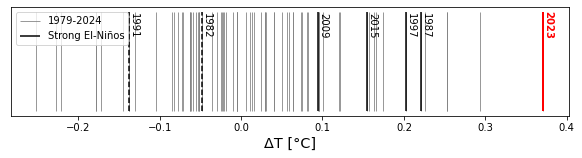

In [12]:

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt.t2m, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt.sel(year = 1982).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1987).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 1991).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1997).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2009).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2015).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt_composite.year.values: 
    x = dt.sel(year = y).t2m
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dt.sel(year= 2023).t2m
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔT [°C]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dt.t2m")

plt.legend(loc = 'upper left')
fig.savefig('output/Fig1a.svg', dpi = 600, bbox_inches='tight')



# Ocean Basins

## calculate thte surface area, so contributions can be area weighted

In [23]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(time = slice('1979', '2023'))

ocean_mask = ~sst.isel(time = 1).sst.isnull()

In [24]:
sst = sst.where(sst.time.dt.month.isin([8,9,10]), drop=True).groupby('time.year').mean()

In [25]:
weights = np.cos(np.deg2rad(sst.lat))
sst['ocean_mean'] = sst.sst.weighted(weights).mean(['lat', 'lon'])

In [26]:
clim = sst.ocean_mean.sel(year = slice('1991', '2020')).mean()
sst['anom'] = sst.ocean_mean - clim

## t2m

In [27]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)


#define na_mask as  all of 1.NA SPSS, 2.NA STSS, 3.NA STPS
#after Fay and McKinley 2014
#see https://github.com/RECCAP2-ocean/R2-shared-resources/blob/master/data/regions/README.md

npol_mask = masks.open_ocean.isin([4])
na_mask = masks.open_ocean.isin([1]).where(masks.lat>=0)
sa_mask = masks.open_ocean.isin([1]).where(masks.lat<0)
southern_mask = masks.open_ocean.isin([5])
tropical_pacific_mask = masks.open_ocean.isin([2,3]).where((masks.lat>=-15) & (masks.lat<=25))
extratropical_pacific_mask = masks.open_ocean.isin([2,3]).where((masks.lat<-15) | (masks.lat>25))
#sextrop_pacific_mask = masks.open_ocean.isin([2]).where((masks.lat<-20))
#nextrop_pacific_mask = masks.open_ocean.isin([2]).where((masks.lat>20))
ocean_mask = masks.open_ocean.isin([1,2,3,4,5])

In [28]:
fp = '/data/jmex/ERA5/monthly/recent/era5_t2m.nc'
t2m = xr.open_dataset(fp).sel(valid_time = slice('1979', None))

#change variable names
t2m = t2m.rename({'latitude':'lat', 'longitude':'lon'})
t2m = t2m.drop_vars(['number', 'expver'])


t2m = t2m.rename({'valid_time':'time'})
t2m['time'] = pd.to_datetime(t2m['time'].values.astype(str), format='%Y-%m-%d')


In [29]:
#take aso season only
t2m = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()


In [30]:
clim = t2m.sel(year = slice('1991', '2020')).mean('year')
t2m['anom'] = t2m.t2m - clim.t2m

In [31]:
t2m = t2m.interp(lat = masks.lat, lon = masks.lon, method='nearest')
t2m = t2m.where(masks.seamask ==1)

In [32]:
weights = np.cos(np.deg2rad(ocean_mask.lat))


ocean_surface = ocean_mask.weighted(weights).sum()

In [33]:
#compute all regional contributions
npol = t2m.where(npol_mask).weighted(weights).mean(['lat', 'lon'])
npol = npol * (npol_mask).weighted(weights).sum()/ocean_surface

trop_pac = t2m.where(tropical_pacific_mask).weighted(weights).mean(['lat', 'lon'])
trop_pac = trop_pac * tropical_pacific_mask.weighted(weights).sum()/ocean_surface

#nextrop_pac = t2m.where(nextrop_pacific_mask).weighted(weights).mean(['lat', 'lon'])
#nextrop_pac = nextrop_pac * nextrop_pacific_mask.weighted(weights).sum()/ocean_surface

#sextrop_pac = t2m.where(sextrop_pacific_mask).weighted(weights).mean(['lat', 'lon'])
#sextrop_pac = sextrop_pac * sextrop_pacific_mask.weighted(weights).sum()/ocean_surface

extrop_pac = t2m.where(extratropical_pacific_mask).weighted(weights).mean(['lat', 'lon'])
extrop_pac = extrop_pac * extratropical_pacific_mask.weighted(weights).sum()/ocean_surface



natl = t2m.where(na_mask).weighted(weights).mean(['lat', 'lon'])
natl = natl * na_mask.weighted(weights).sum()/ocean_surface

satl = t2m.where(sa_mask).weighted(weights).mean(['lat', 'lon'])
satl = satl * sa_mask.weighted(weights).sum()/ocean_surface

sou = t2m.where(southern_mask).weighted(weights).mean(['lat', 'lon'])
sou = sou * southern_mask.weighted(weights).sum()/ocean_surface


In [34]:
ls = [trop_pac, extrop_pac, sou, satl, natl, npol]
#ls = [ind, trop_pac, nextrop_pac, sextrop_pac, sou, satl, natl, npol]

In [36]:
ds_fig1b = xr.Dataset(
    {
        "npol": npol["anom"],
        "trop_pac": trop_pac["anom"],
        "extrop_pac": extrop_pac["anom"],
        "natl": natl["anom"],
        "satl": satl["anom"],
        "sou": sou["anom"],
    }
)

ds_fig1b.to_netcdf("preprocessed_data/fig1b.nc")

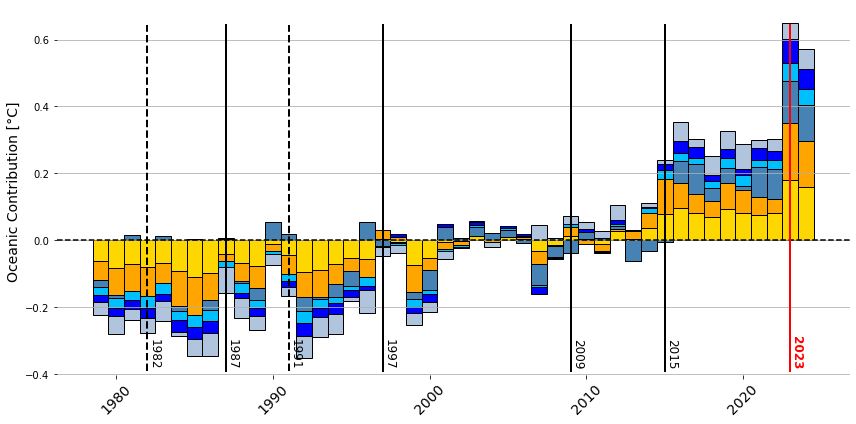

In [37]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))


labels = ['Tropical Pacific', 'Extrop Pacific', 
                    'Southern Ocean', 'South Atlantic', 'North Atlantic', 'Arctic']

colors = [ 'gold', 'orange', 'steelblue', 'deepskyblue', 'blue', 'lightsteelblue']



bottom_pos = np.zeros(len(npol['year']))
bottom_neg = np.zeros(len(npol['year']))

for i, r in enumerate(ls):
    values = r['anom'].values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
#ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Oceanic Contribution [°C]', fontsize = 14, fontweight = 'normal')

# Define the years of interest and their positions on the x-axis
years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]

for year in years_of_interest:
    if year == 2023:
        ax.annotate(str(year), (year, -0.375), rotation = 270, fontsize = 12, fontweight = 'bold', color = 'r')
    else:
        ax.annotate(str(year), (year, -0.375), rotation = 270, fontsize = 12)
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    if year in [1982, 1991]:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='--', color='k', linewidth=2)
    elif year == 2023:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='r', linewidth=2)
    else:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='k', linewidth=2)
    


"""for year in years_of_interest:
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    y = bottom_neg[np.where(r.year.values == year)[0]]
    height = -bottom_neg[np.where(r.year.values == year)[0]]+bottom_pos[np.where(r.year.values == year)[0]]
    if year in [1982, 1991]:
        rect = plt.Rectangle((year-0.5, y), 1, height , linewidth=4, linestyle = '--', edgecolor='k', facecolor='none')
    else:
        rect = plt.Rectangle((year-0.5, y), 1, height , linewidth=4, linestyle='-', edgecolor='k', facecolor='none')

    # Add the rectangle to the plot
    ax.add_patch(rect)
"""
'''
ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('ONI', color='k', fontsize = 12)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor='k')
ax2.plot(oni.year,oni.oni9, marker = 'o', c = 'k', linestyle = '--')
#ax.legend()    

ax.set_ylim(-0.5,0.7)
ax2.set_ylim(-5/12 * 6,7/12 *6)
'''
for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()

fig.savefig('output/Fig1b.svg', dpi = 600, bbox_inches='tight')
    

#ax.legend()

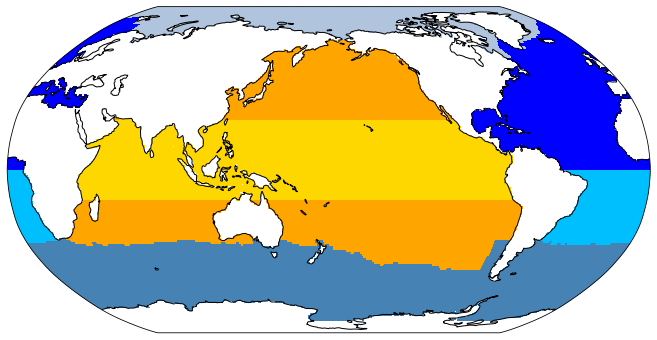

In [27]:
#make a plot in robinson projection of all the regional masks using the corect coloring
#plotting for the ind_mask, tropical_pacific_mask, extratropical_pacific_mask, southern_mask, sa_mask, na_mask, npol_mask


import cartopy.crs as ccrs

projection = ccrs.Robinson(central_longitude=180)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=projection)

masks_to_plot = {
    'Tropical Pacific': tropical_pacific_mask,
#    'Extratropical Pacific': extratropical_pacific_mask,
    'Extrop Pacific': extratropical_pacific_mask,
    'Southern Ocean': southern_mask,
    'South Atlantic': sa_mask,
    'North Atlantic': na_mask,
    'Arctic': npol_mask
}   

for (region, mask), color in zip(masks_to_plot.items(), colors):
    masked_data = mask.where(mask, other=np.nan)
    masked_data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                               cmap=mcolors.ListedColormap([color]),
                               add_colorbar=False,
                               alpha=1)


ax.coastlines()

fig.savefig('output/Fig1b2.svg', dpi = 600, bbox_inches='tight')



In [28]:
import pandas as pd
import xarray as xr

# Step 1: Read the text file into a DataFrame
file_path = '/data/jmex/NOAA/oni.data'
df = pd.read_csv(file_path, delim_whitespace=True, header=1, skipfooter=8, engine='python')

# Step 2: Create a list of months and rename the columns accordingly
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df.columns = ['year'] + months

# Step 3: Reshape the DataFrame to long format for easier time indexing
df_long = df.melt(id_vars=['year'], var_name='month', value_name='oni')

# Step 4: Combine 'year' and 'month' into a single datetime column
df_long['time'] = pd.to_datetime(df_long['year'].astype(str) + df_long['month'], format='%Y%b')

# Step 5: Drop the now-unnecessary 'year' and 'month' columns
df_long = df_long.drop(columns=['year', 'month'])

# Step 6: Sort the DataFrame by the 'time' column
df_long = df_long.sort_values(by='time')

# Step 7: Convert to xarray Dataset with 'time' as the coordinate
ds = df_long.set_index('time').to_xarray().sel(time = slice('1979', '2024')).drop_isel(time = -1)


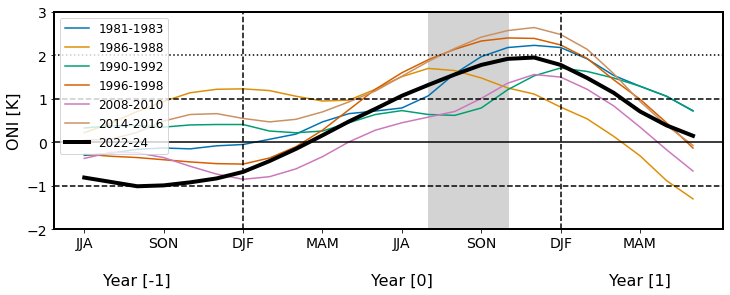

In [29]:

# Define event years
c_years = [1982, 1987, 1991, 1997, 2009, 2015]

# Get a nice color palette (e.g., Set2, colorblind, Paired)
colors = sns.color_palette("colorblind", len(c_years))  # Try "colorblind", "Set1", or "tab10"

fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharey=True)

# Loop through historical years with better colors
for i, c in enumerate(c_years):
    ds_sel = ds.sel(time=slice(f"{c-1}-07", f"{c+1}-06"))
    ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.oni, label=f"{c-1}-{c+1}", color=colors[i])

# Recent period in black, thicker line
ds_sel = ds.sel(time=slice("2022-07", "2024-06"))
ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.oni, label="2022-24", color="k", linewidth=4)



#graphical stuff
# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months



ax.axhline(0, c = 'k')
ax.axhline(1, c = 'k', linestyle = '--')
ax.axhline(-1, c = 'k', linestyle = '--')
ax.axhline(2, c = 'k', linestyle = ':')
ax.axhline(-2, c = 'k', linestyle = ':')

ax.fill_between(x = [13,16], y1 = 3, y2 = -3, color = 'lightgrey' )


ax.set_ylabel('ONI [K]', fontsize = 16, fontweight = 'normal')
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize =16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(-2, 3)


ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

    # Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

    # Second row: Manually add every 8th label slightly lower
for i in [2,12,21]:
    ax.text(i, -3, f"Year [{i//10 -1}]", ha="center", va="top", fontsize=16, color="black",
            fontweight ='normal')




ax.legend(fontsize= 12, loc = 'upper left')
#ax.set_title('ONI Evolution during El-Nino', fontweight = 'normal');

# Add title and format ticks
fig.savefig('output/Fig1c.svg', dpi = 600, bbox_inches='tight')

